<a href="https://colab.research.google.com/github/Poojalakshmi271/AGENTIC-AI/blob/main/NLP_GloVe%2C_BERT%2C_TF_IDF_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
uciml_sms_spam_collection_dataset_path = kagglehub.dataset_download('uciml/sms-spam-collection-dataset')
danielwillgeorge_glove6b100dtxt_path = kagglehub.dataset_download('danielwillgeorge/glove6b100dtxt')
andreshg_masksforwordclouds_path = kagglehub.dataset_download('andreshg/masksforwordclouds')
image_source = kagglehub.dataset_download("andreshg/masksforwordclouds")

print('Data source import complete.')

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Using Colab cache for faster access to the 'glove6b100dtxt' dataset.
Using Colab cache for faster access to the 'masksforwordclouds' dataset.
Using Colab cache for faster access to the 'masksforwordclouds' dataset.
Data source import complete.


In [ ]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/sms-spam-collection-dataset/spam.csv
/kaggle/input/masksforwordclouds/twitter_mask2.png
/kaggle/input/masksforwordclouds/.nfs0000000048430f160000026a
/kaggle/input/masksforwordclouds/twitter_mask4.jpg
/kaggle/input/masksforwordclouds/twitter_mask3.jpg
/kaggle/input/masksforwordclouds/book-logo-1.jpg
/kaggle/input/masksforwordclouds/twitter_mask.png
/kaggle/input/masksforwordclouds/wordcloud-man.png
/kaggle/input/masksforwordclouds/twitter_mask3.png


In [ ]:
import re
import string
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from collections import Counter

from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tqdm import tqdm
import os
import nltk
import spacy
import random
from spacy.util import compounding
from spacy.util import minibatch

from collections import defaultdict
from collections import Counter

import keras
from keras.models import Sequential
from keras.initializers import Constant
from keras.layers import (LSTM,
                          Embedding,
                          BatchNormalization,
                          Dense,
                          TimeDistributed,
                          Dropout,
                          Bidirectional,
                          Flatten,
                          GlobalMaxPool1D)
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.layers import Embedding
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    accuracy_score
)

In [ ]:
primary_blue="#496595"
primary_blue2="#85a1c1"
primary_blue3="#3f4d63"
primary_grey="#c6ccd8"
primary_black="#202022"
primary_bgcolor="#f4f0ea"

primary_green=px.colors.qualitative.Plotly[2]


In [ ]:
df=pd.read_csv("/kaggle/input/sms-spam-collection-dataset/spam.csv", encoding="latin-1")
df=df.dropna(how="any", axis=1)
df.columns=['target','message']

df.head()


,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['message_len']=df['message'].apply(lambda x:len(x.split()))
df.head()

,target,message,message_len
0,ham,"Go until jurong point, crazy.. Available only ...",20
1,ham,Ok lar... Joking wif u oni...,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,28
3,ham,U dun say so early hor... U c already then say...,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",13


In [ ]:
max(df['message_len'])

171

In [ ]:
balance_counts=df.groupby('target')['target'].agg('count')
balance_counts

,target
target,
ham,4825
spam,747


In [ ]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=['ham'],
    y=[balance_counts[0]],
    name='ham',
    text=[balance_counts[0]],
    textposition='auto',
    marker_color=primary_blue
))
fig.add_trace(go.Bar(
    x=['spam'],
    y=[balance_counts[1]],
    name='spam',
    text=[balance_counts[1]],
    textposition='auto',
    marker_color=primary_grey
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Dataset distribution by target</span>'
)
fig.show()




/tmp/ipykernel_3964/2850545842.py:4: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3964/2850545842.py:6: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3964/2850545842.py:12: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_3964/2850545842.py:14: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (con

In [ ]:
ham_df = df[df['target'] == 'ham']['message_len'].value_counts().sort_index()
spam_df = df[df['target'] == 'spam']['message_len'].value_counts().sort_index()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=ham_df.index,
    y=ham_df.values,
    name='ham',
    fill='tozeroy',
    marker_color=primary_blue,
))
fig.add_trace(go.Scatter(
    x=spam_df.index,
    y=spam_df.values,
    name='spam',
    fill='tozeroy',
    marker_color=primary_grey,
))
fig.update_layout(
    title='<span style="font-size:32px; font-family:Times New Roman">Data Roles in Different Fields</span>'
)
fig.update_xaxes(range=[0, 70])
fig.show()

In [ ]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,
    remove links, remove punctuation and remove words containing numbers.'''

    text = str(text).lower()

    text = re.sub(r'\[.*?\]', ' ', text)

    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    text = re.sub(r'<.*?>+', ' ', text)

    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)

    text = re.sub(r'\n', ' ', text)

    text = re.sub(r'\w*\d\w*', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
df['message_clean'] = df['message'].apply(clean_text)
df.head()

,target,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",20,go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,6,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,11,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",13,nah i don t think he goes to usf he lives arou...


In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = stopwords.words('english')

more_stopwords = ['u', 'im', 'c']

stop_words = stop_words + more_stopwords

def remove_stopwords(text):

    text = ' '.join(
        word for word in text.split(' ')
        if word not in stop_words
    )

    return text

df['message_clean'] = df['message_clean'].apply(remove_stopwords)

df.head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,target,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,6,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entry wkly comp win fa cup final tkts may...
3,0,U dun say so early hor... U c already then say...,11,dun say early hor already say
4,0,"Nah I don't think he goes to usf, he lives aro...",13,nah think goes usf lives around though


In [ ]:
stemmer=nltk.SnowballStemmer("english")

def stemm_text(text):
  # Ensure text is not empty before splitting and joining
  if not text.strip():
      return ""
  text=' '.join(stemmer.stem(word) for word in text.split(' ')) # Changed '' to ' '
  return text

In [ ]:
df['message_clean']=df['message_clean'].apply(stemm_text)
df.head()

,target,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,6,ok lar joke wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts may...
3,0,U dun say so early hor... U c already then say...,11,dun say earli hor alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",13,nah think goe usf live around though


In [ ]:
def preprocess_data(text):
  #clean punctuation
  text=clean_text(text)
  #remove stopwords
  # Ensure text is not empty before splitting and joining
  if not text.strip():
      return ""
  text=' '.join(word for word in text.split(' ') if word not in stop_words)
  # Ensure text is not empty before splitting and joining for stemming
  if not text.strip():
      return ""
  text=' '.join(stemmer.stem(word) for word in text.split(' ')) # Changed '' to ' '
  return text

In [ ]:
df['message_clean']=df['message_clean'].apply(preprocess_data)
df.head()

,target,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,6,ok lar joke wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts may...
3,0,U dun say so early hor... U c already then say...,11,dun say ear hor alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",13,nah think goe usf live around though


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
le.fit(df['target'])
df['target']=le.transform(df['target'])
df.head()

,target,message,message_len,message_clean
0,0,"Go until jurong point, crazy.. Available only ...",20,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,6,ok lar joke wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,28,free entri wkli comp win fa cup final tkts may...
3,0,U dun say so early hor... U c already then say...,11,dun say ear hor alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",13,nah think goe usf live around though


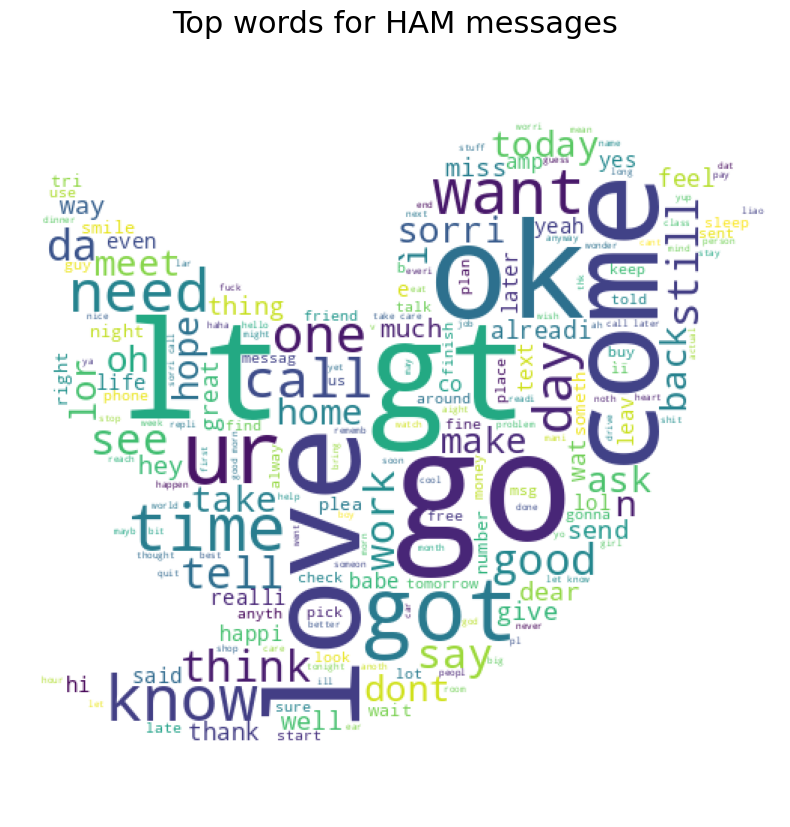

In [ ]:
twitter_mask = np.array(Image.open('/kaggle/input/masksforwordclouds/twitter_mask3.jpg'))

wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)

wc.generate(
    ' '.join(
        text for text in df.loc[df['target'] == 0, 'message_clean']
        .dropna()
        .astype(str)
    )
)

plt.figure(figsize=(18,10))

plt.title(
    'Top words for HAM messages',
    fontdict={'size': 22, 'verticalalignment': 'bottom'}
)

plt.imshow(wc)

plt.axis("off")

plt.show()

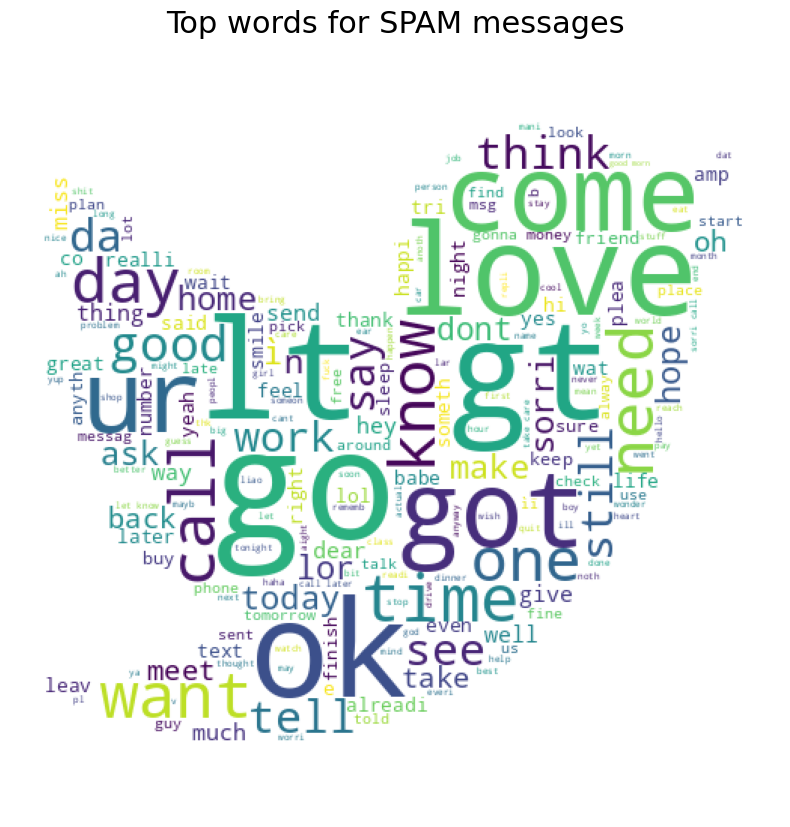

In [ ]:
twitter_mask = np.array(Image.open('/kaggle/input/masksforwordclouds/twitter_mask3.jpg'))

wc = WordCloud(
    background_color='white',
    max_words=200,
    mask=twitter_mask,
)

wc.generate(
    ' '.join(
        text for text in df.loc[df['target'] == 0, 'message_clean']
        .dropna()
        .astype(str)
    )
)

plt.figure(figsize=(18,10))

plt.title(
    'Top words for SPAM messages',
    fontdict={'size': 22, 'verticalalignment': 'bottom'}
)

plt.imshow(wc)

plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
x = df['message_clean']
y = df['target']
x_train,x_test,y_train,y_test=train_test_split(x,y, random_state=42)
print(len(x_train),len(y_train))
print(len(x_test),len(y_test))

4179 4179
1393 1393


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vect=CountVectorizer()
vect.fit(x_train)

CountVectorizer()

In [ ]:
x_train_dtm=vect.transform(x_train)
x_test_dtm=vect.transform(x_test)

In [ ]:
vect_tunned=CountVectorizer(stop_words='english', ngram_range=(1,2),min_df=0.001,max_df=0.7)
vect_tunned.fit(x_train)

CountVectorizer(max_df=0.7, min_df=0.001, ngram_range=(1, 2),
                stop_words='english')

In [ ]:
from sklearn.feature_extraction.text import TfidfTransformer

tfidf_transformer=TfidfTransformer()
tfidf_transformer.fit(x_train_dtm)
x_train_tfidf=tfidf_transformer.transform(x_train_dtm)
x_test_tfidf=tfidf_transformer.transform(x_test_dtm)

In [ ]:
word_tokenizer=Tokenizer()
word_tokenizer.fit_on_texts(x_train)

vocab_length=len(word_tokenizer.word_index) + 1
vocab_length

5225